In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore, kurtosis, skew

print('Done Importing')

Done Importing


In [2]:
data = pd.read_csv('wine.csv')
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [4]:
data = data.drop_duplicates().reset_index(drop=True)

In [5]:
data.var()

fixed acidity              3.017134
volatile acidity           0.033500
citric acid                0.038235
residual sugar             1.828752
chlorides                  0.002438
free sulfur dioxide      109.145456
total sulfur dioxide    1116.157653
density                    0.000003
pH                         0.024036
sulphates                  0.029127
alcohol                    1.170866
quality                    0.678281
dtype: float64

In [6]:
#shape of data
print('columns: ', data.shape[1])
print('Rows: ', data.shape[0])
data.shape

columns:  12
Rows:  1599


(1599, 12)

# description
* column total sulfur dioxide and free sulfur dioxide has high variance and standard deviation.
* No null value detected.


# univariant analysis

In [7]:
#skewed and kurtosis
print('skew: \n', data.skew())
print('--'*20)
print('Kurtosis: \n', data.kurtosis())

skew: 
 fixed acidity           0.941041
volatile acidity        0.729279
citric acid             0.312726
residual sugar          4.548153
chlorides               5.502487
free sulfur dioxide     1.226579
total sulfur dioxide    1.540368
density                 0.044778
pH                      0.232032
sulphates               2.406505
alcohol                 0.859841
quality                 0.192407
dtype: float64
----------------------------------------
Kurtosis: 
 fixed acidity            1.049673
volatile acidity         1.249243
citric acid             -0.788921
residual sugar          29.364592
chlorides               38.624653
free sulfur dioxide      1.892691
total sulfur dioxide     4.042257
density                  0.830659
pH                       0.879790
sulphates               11.102282
alcohol                  0.159739
quality                  0.340256
dtype: float64


In [12]:
pd.DataFrame(kurtosis(data, fisher = False, keepdims = True), columns = data.columns)#pearson's kurtosis where norm = 3

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,4.124856,4.217963,2.209717,31.524438,44.581708,5.01349,6.794172,3.927411,3.800671,14.679884,3.195654,3.292031


In [10]:
pd.DataFrame(kurtosis(data, fisher = True, keepdims = True), columns = data.columns)#fisher where norm = 0

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,1.124856,1.217963,-0.790283,28.524438,41.581708,2.01349,3.794172,0.927411,0.800671,11.679884,0.195654,0.292031


In [9]:

X = data.drop(columns = ['quality'])
z_score = zscore(X, ddof = 1)
threshold = 3

is_not_outliers = (np.abs(z_score)<threshold)

valid_rows = is_not_outliers.all(axis =1)
clean_data = data[valid_rows]




# kurtosis analysis
* residual sugar, chlorides, free sulfur dioxidem ,total sulfur dioxide, sulphates are luptokurtric.
* citric acid is a bit platykurtic

# univariant analysis

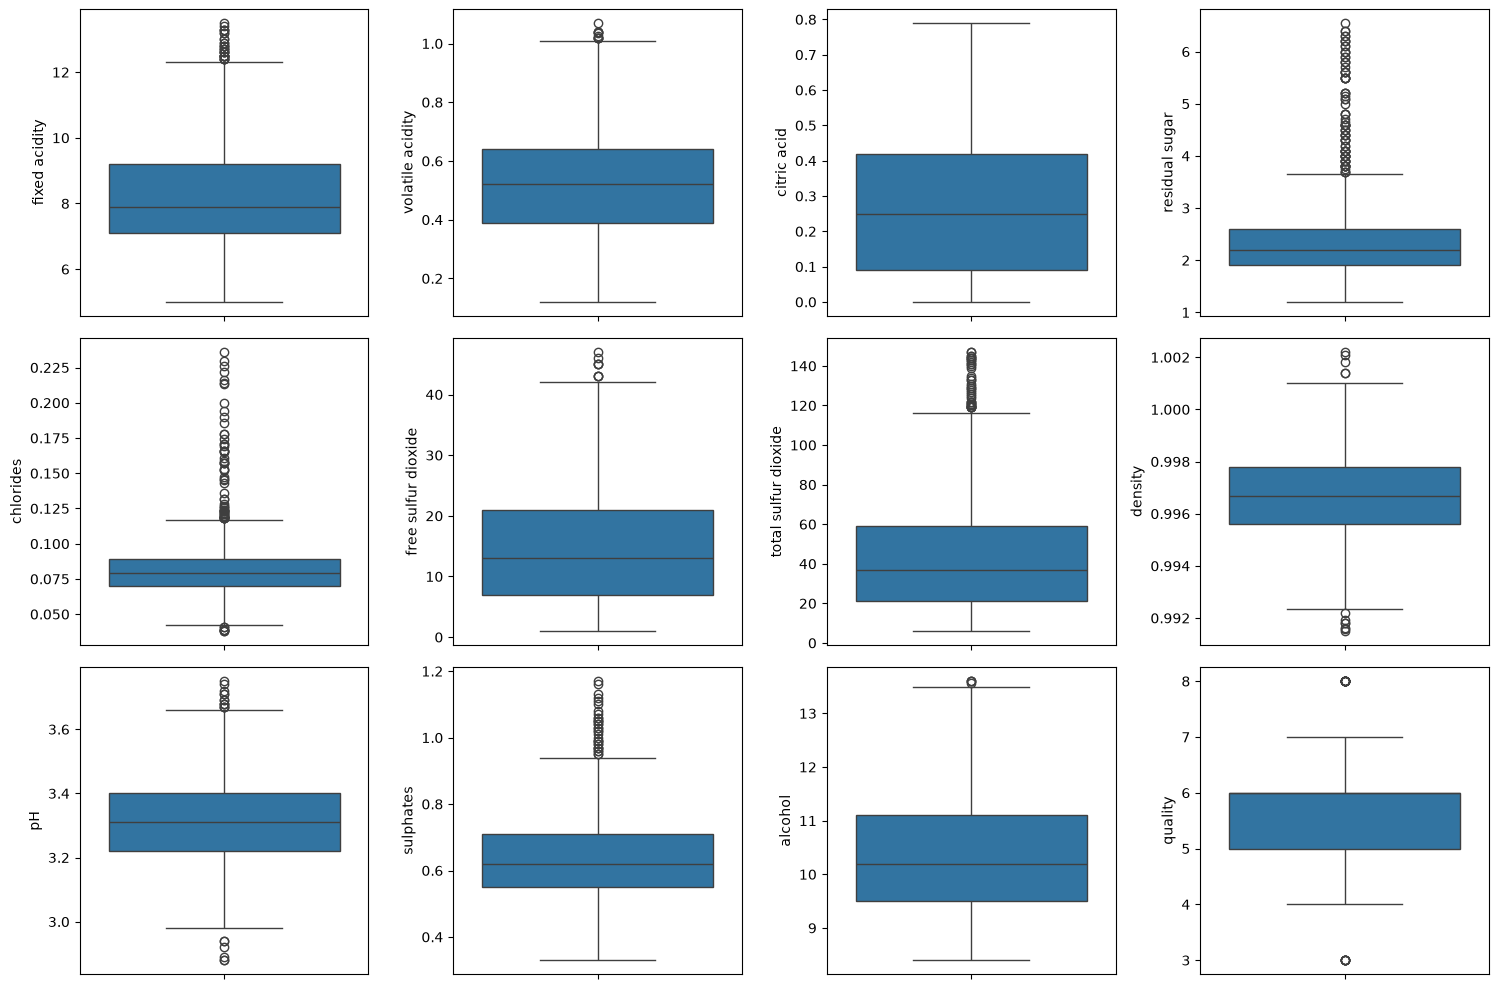

In [27]:
fig, axes = plt.subplots(3, 4, figsize=(15, 10))
for ax, col in zip(axes.flatten(), clean_data.columns):
    sns.boxplot(clean_data[col], ax=ax)
plt.tight_layout()
plt.savefig('boxplot of each column')

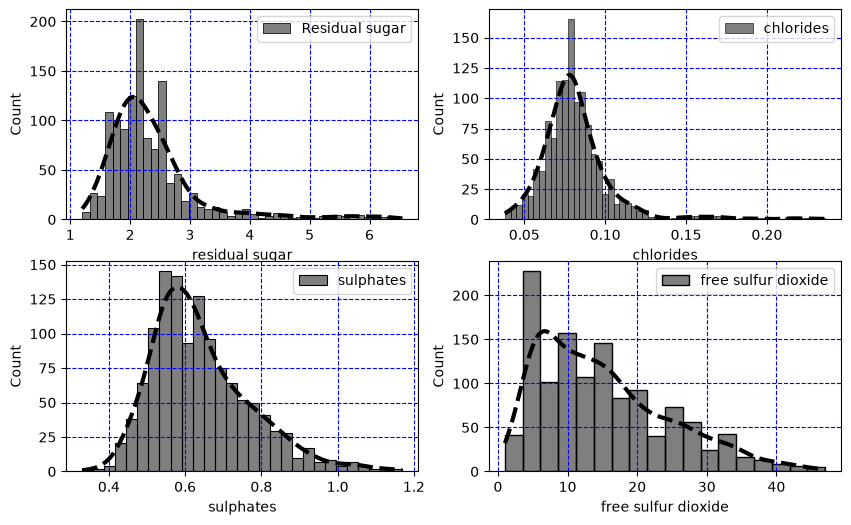

<Figure size 1100x1000 with 0 Axes>

In [13]:
plt.figure(figsize = (10, 6))

plt.subplot(2,2,1)
sns.histplot(clean_data, x = 'residual sugar', kde = True, label = 'Residual sugar',color = 'black',line_kws = {  'linewidth': 3, 'linestyle': '--','color': 'black'}
        )
plt.legend()
plt.grid(linestyle = '--', color = 'b')


plt.subplot(2,2,2)
sns.histplot(clean_data, x = 'chlorides', kde = True, label = 'chlorides',color = 'black',line_kws = {  'linewidth': 3, 'linestyle': '--','color': 'black'}
        )
plt.legend()
plt.grid(linestyle = '--', color = 'b')


plt.subplot(2,2,3)
sns.histplot(clean_data, x = 'sulphates', kde = True, label = 'sulphates',color = 'black',line_kws = {  'linewidth': 3, 'linestyle': '--','color': 'black'}
        )
plt.legend()
plt.grid(linestyle = '--', color = 'b')


plt.subplot(2,2,4)
sns.histplot(clean_data, x = 'free sulfur dioxide', kde = True, label = 'free sulfur dioxide',color = 'black',line_kws = {  'linewidth': 3, 'linestyle': '--','color': 'black'}
        )
plt.legend()
plt.grid(linestyle = '--', color = 'b')
plt.figure (figsize = (11, 10))

plt.show()

/tmp/ipykernel_23561/2151287432.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(clean_data, x = 'quality', palette = 'husl')


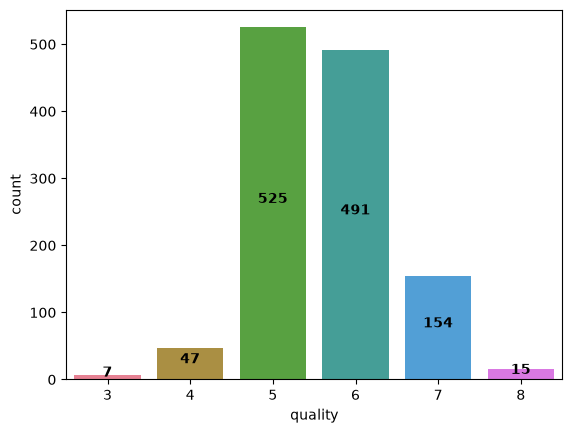

In [14]:

ax = sns.countplot(clean_data, x = 'quality', palette = 'husl')
for container in ax.containers:
    
    ax.bar_label(container, padding = 3, fontsize = 10, weight = 'bold', label_type = 'center')
plt.show()

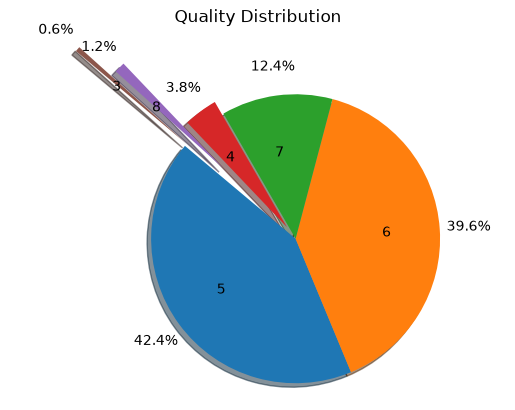

In [15]:
counts = clean_data['quality'].value_counts()

# 2. Plot pie chart
plt.pie(
    counts,
    labels=counts.index,  # Adds labels for each category (e.g., 3, 4, 5, 6, 7)
    autopct='%.1f%%',  # Displays percentages rounded to 2 decimal places
    startangle=140,  # Rotates start for better alignment
    explode = [0,0,0,0.1,0.7,1],
    shadow = True,
    labeldistance = 0.6,
    pctdistance = 1.2
)

plt.title('Quality Distribution')
plt.axis('equal')  # Ensures pie chart is rendered as a circle
plt.show()

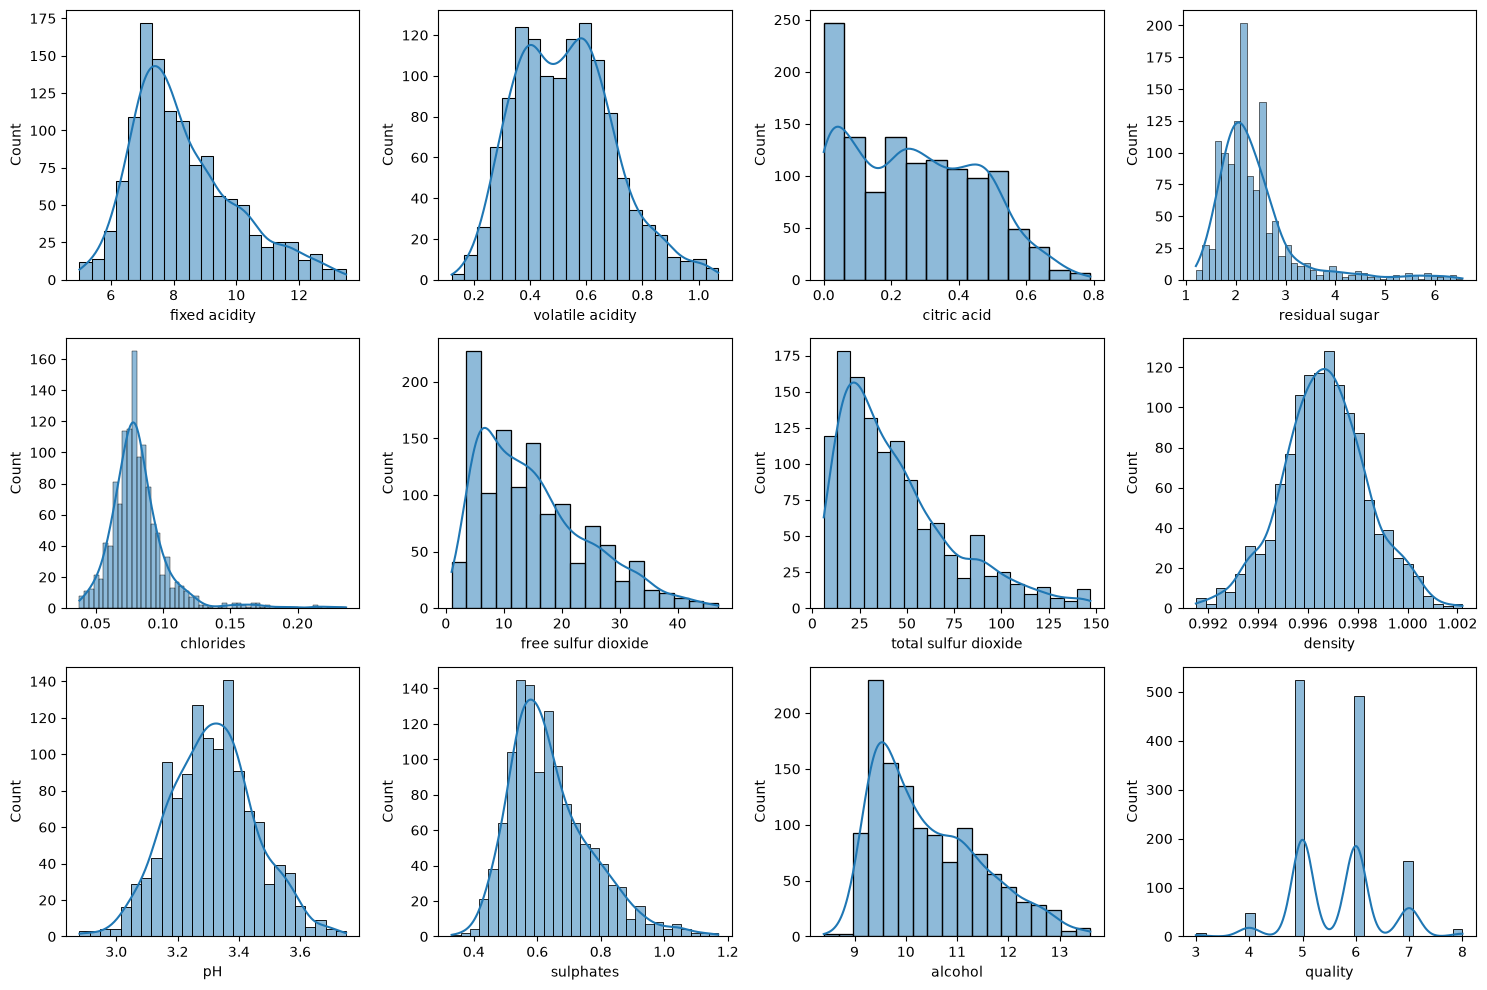

In [26]:
fig, axes = plt.subplots(3, 4, figsize=(15, 10))
for ax, col in zip(axes.flatten(), clean_data.columns):
    sns.histplot(clean_data[col], kde=True, ax=ax)
plt.tight_layout()
plt.savefig('histplot of each column')

# Bivarient Analysis

<Axes: xlabel='citric acid', ylabel='Density'>

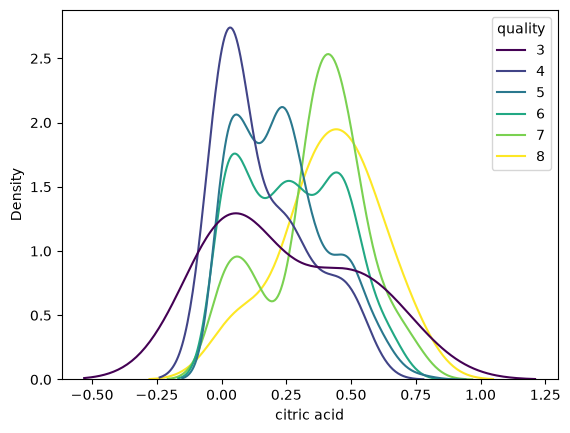

In [17]:
sns.kdeplot(clean_data, x = 'citric acid', hue = 'quality', common_norm = False, fill = False ,thresh = 0.05, levels = 10, palette = 'viridis')

<Axes: xlabel='Count', ylabel='citric acid'>

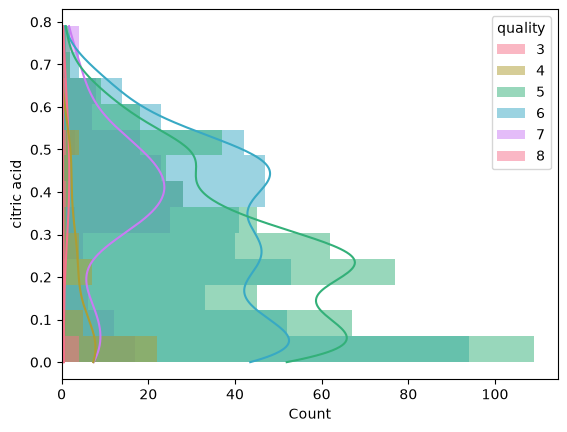

In [19]:
sns.histplot(
    clean_data, 
    hue='quality', 
    y='citric acid', 
    kde=True, 
    fill=True, 
    color=(0, 0, 0,0), 
    edgecolor=(0, 0, 0, 0),
    palette = 'husl'
)

In [20]:
data.corr()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.255124,0.667437,0.111025,0.085886,-0.140580,-0.103777,0.670195,-0.686685,0.190269,-0.061596,0.119024
volatile acidity,-0.255124,1.000000,-0.551248,-0.002449,0.055154,-0.020945,0.071701,0.023943,0.247111,-0.256948,-0.197812,-0.395214
citric acid,0.667437,-0.551248,1.000000,0.143892,0.210195,-0.048004,0.047358,0.357962,-0.550310,0.326062,0.105108,0.228057
residual sugar,0.111025,-0.002449,0.143892,1.000000,0.026656,0.160527,0.201038,0.324522,-0.083143,-0.011837,0.063281,0.013640
chlorides,0.085886,0.055154,0.210195,0.026656,1.000000,0.000749,0.045773,0.193592,-0.270893,0.394557,-0.223824,-0.130988
free sulfur dioxide,-0.140580,-0.020945,-0.048004,0.160527,0.000749,1.000000,0.667246,-0.018071,0.056631,0.054126,-0.080125,-0.050463
total sulfur dioxide,-0.103777,0.071701,0.047358,0.201038,0.045773,0.667246,1.000000,0.078141,-0.079257,0.035291,-0.217829,-0.177855
density,0.670195,0.023943,0.357962,0.324522,0.193592,-0.018071,0.078141,1.000000,-0.355617,0.146036,-0.504995,-0.184252
pH,-0.686685,0.247111,-0.550310,-0.083143,-0.270893,0.056631,-0.079257,-0.355617,1.000000,-0.214134,0.213418,-0.055245
sulphates,0.190269,-0.256948,0.326062,-0.011837,0.394557,0.054126,0.035291,0.146036,-0.214134,1.000000,0.091621,0.248835


In [21]:
cor = clean_data.corrwith(data['quality'])
cor

fixed acidity           0.131621
volatile acidity       -0.369907
citric acid             0.239204
residual sugar          0.043436
chlorides              -0.131943
free sulfur dioxide    -0.067511
total sulfur dioxide   -0.222127
density                -0.190830
pH                     -0.082619
sulphates               0.378255
alcohol                 0.501239
quality                 1.000000
dtype: float64

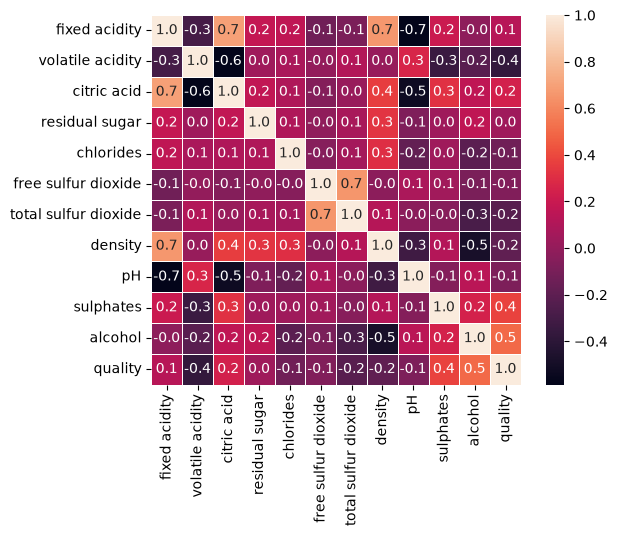

In [28]:
sns.heatmap(clean_data.corr(), annot  = True, linewidth = .5, square = True, fmt = '.1f', robust = True)
plt.savefig('heatmap of corr')

/home/anuj/anaconda3/lib/python3.14/site-packages/seaborn/regression.py:411: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x, y, **kws)


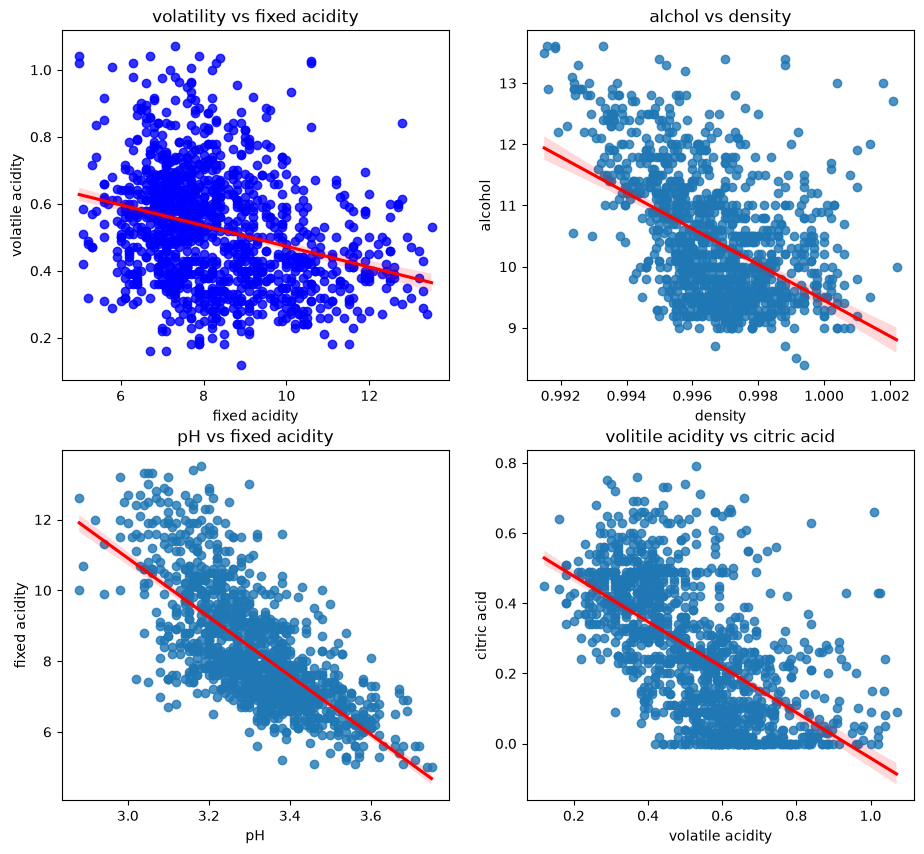

In [29]:
plt.figure (figsize = (11, 10))

plt.subplot(2,2,1)
sns.regplot(clean_data, x = 'fixed acidity', y = 'volatile acidity',color = 'b', line_kws = {'color':'r'}, scatter_kws = {'cmap':'viridis'})
plt.title('volatility vs fixed acidity')


plt.subplot(2,2,2)
sns.regplot(clean_data, y ='alcohol', x='density', line_kws = {'color':'r'})
plt.title('alchol vs density')


plt.subplot(2,2,3)
sns.regplot(clean_data, x = 'pH', y = 'fixed acidity', line_kws={'color':'r'})
plt.title('pH vs fixed acidity')

plt.subplot(2,2,4)
sns.regplot(clean_data, x = 'volatile acidity', y = 'citric acid', line_kws = {'color':'r'})
plt.title('volitile acidity vs citric acid')

plt.savefig('scatter negative plot')
plt.show()

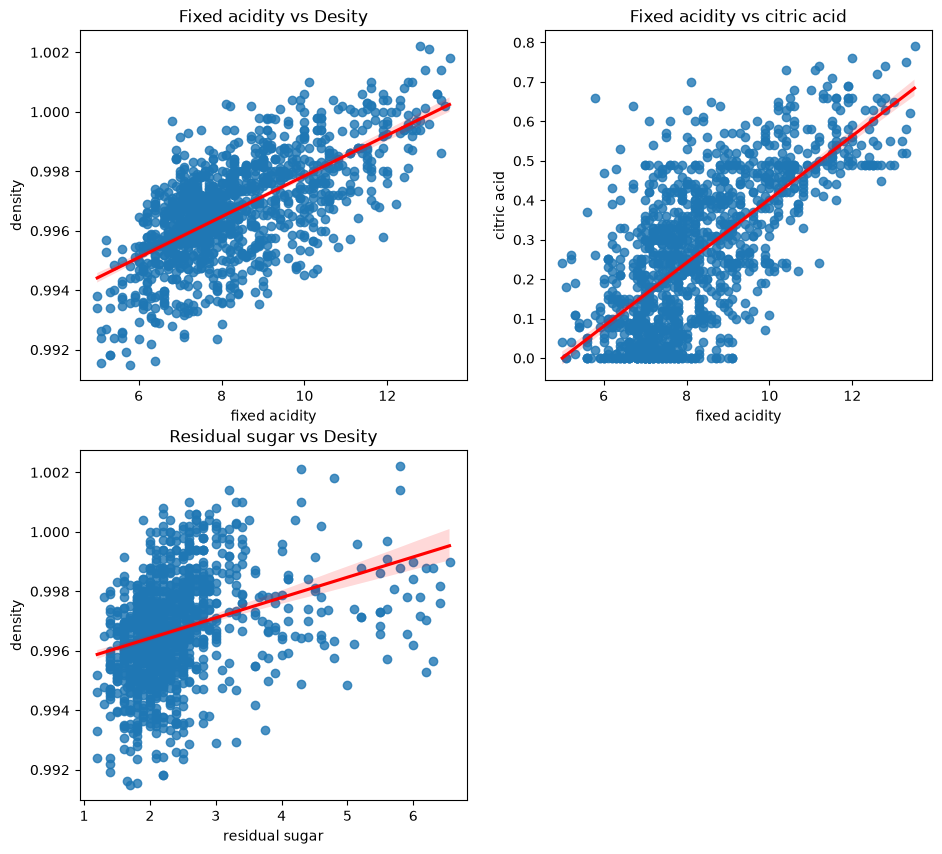

In [30]:
plt.figure (figsize = (11, 10))

plt.subplot(2,2,1)
sns.regplot(clean_data, x = 'fixed acidity', y = 'density', line_kws = {'color': 'r'})
plt.title('Fixed acidity vs Desity')

plt.subplot(2,2,2)
sns.regplot(clean_data, x = 'fixed acidity', y = 'citric acid', line_kws = {'color': 'r'})
plt.title('Fixed acidity vs citric acid')

plt.subplot(2,2,3)
sns.regplot(clean_data, x = 'residual sugar', y = 'density', line_kws = {'color': 'r'})
plt.title('Residual sugar vs Desity')

plt.savefig('scatter positive corr')
plt.show()
